In [2]:
import sys
sys.path.append("/users/xn22103/atmospherics-tools/fast-osc-feedback/")

import polars as pl
import uproot
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt

caf_tree = uproot.open("/storage/1/st15719/caf_new_sum.2.6M_weighted.root")["cafTree"]

Enu_e_had   = "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.e_had"
Enu_e_calo  = "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.e_calo"
Enu_mu_had  = "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.mu_had"
Enu_mu_range= "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.mu_range"
PDG         = "rec/mc/mc.nu/mc.nu.pdg"

caf_data = caf_tree.arrays([Enu_e_had, Enu_e_calo, Enu_mu_had, Enu_mu_range, PDG])

caf_df = pl.from_pandas(ak.to_dataframe(caf_data, how = "outer"))
caf_df.columns = ["Enu_e_had","Enu_e_calo","Enu_mu_had","Enu_mu_range","PDG"]

reco_pfp_tree = uproot.open("reco_pfp_info.root")["reco_pfp_tree"]
reco_pfp_df = pl.from_pandas(reco_pfp_tree.arrays(library="pd"))

data = pl.concat([caf_df, reco_pfp_df], how="horizontal")

data = data.filter(pl.col("reco_ok") == True)


data = data.with_columns(
	(1 - (pl.col("Enu_e_had") / pl.col("Enu_e_calo"))).alias("inelasticity_e"),
	(1 - (pl.col("Enu_mu_had") / pl.col("Enu_mu_range"))).alias("inelasticity_mu"),
	(pl.col("PDG") < 0).cast(pl.Int64).alias("label"))



data = data.to_pandas()
data = data.dropna()
data

,Enu_e_had,Enu_e_calo,Enu_mu_had,Enu_mu_range,PDG,reco_ok,n_reco_pfps,n_reco_tracks,n_reco_showers,single_hits_energy,n_reco_muons_pions,n_reco_protons,inelasticity_e,inelasticity_mu,label
0,1.237640e+01,28.432413,28.015844,28.529816,-12,True,10,5,4,11.487990,4,1,0.564708,0.018015,1
1,9.994991e-02,0.208079,0.099950,0.322256,-12,True,2,1,0,0.110940,1,0,0.519653,0.689843,1
2,3.063447e-01,1.156426,0.306345,1.201710,-14,True,4,3,0,0.064570,2,1,0.735094,0.745076,1
3,8.884442e-02,0.502835,0.088844,0.593700,14,True,3,2,0,0.002420,1,1,0.823313,0.850355,0
4,3.318707e-03,0.299485,0.003319,0.299201,16,True,2,1,0,0.003319,1,0,0.988919,0.988908,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2651022,-8.104407e-17,0.156685,0.000000,0.256748,14,True,2,1,0,0.000000,1,0,1.000000,1.000000,0
2651023,2.552473e-03,0.169946,0.002552,0.260973,14,True,2,1,0,0.005397,1,0,0.984981,0.990219,0
2651024,1.402719e-02,0.124140,0.014027,0.207403,14,True,3,1,1,0.012165,1,0,0.887005,0.932367,0
2651025,5.641751e-02,1.383207,1.343197,1.471067,12,True,3,1,1,0.102556,0,1,0.959213,0.086923,0


In [3]:
plotting_data = data.drop(columns = ['Enu_e_had','Enu_e_calo','Enu_mu_had','Enu_mu_range'])
plotting_data

,PDG,reco_ok,n_reco_pfps,n_reco_tracks,n_reco_showers,single_hits_energy,n_reco_muons_pions,n_reco_protons,inelasticity_e,inelasticity_mu,label
0,-12,True,10,5,4,11.487990,4,1,0.564708,0.018015,1
1,-12,True,2,1,0,0.110940,1,0,0.519653,0.689843,1
2,-14,True,4,3,0,0.064570,2,1,0.735094,0.745076,1
3,14,True,3,2,0,0.002420,1,1,0.823313,0.850355,0
4,16,True,2,1,0,0.003319,1,0,0.988919,0.988908,0
...,...,...,...,...,...,...,...,...,...,...,...
2651022,14,True,2,1,0,0.000000,1,0,1.000000,1.000000,0
2651023,14,True,2,1,0,0.005397,1,0,0.984981,0.990219,0
2651024,14,True,3,1,1,0.012165,1,0,0.887005,0.932367,0
2651025,12,True,3,1,1,0.102556,0,1,0.959213,0.086923,0


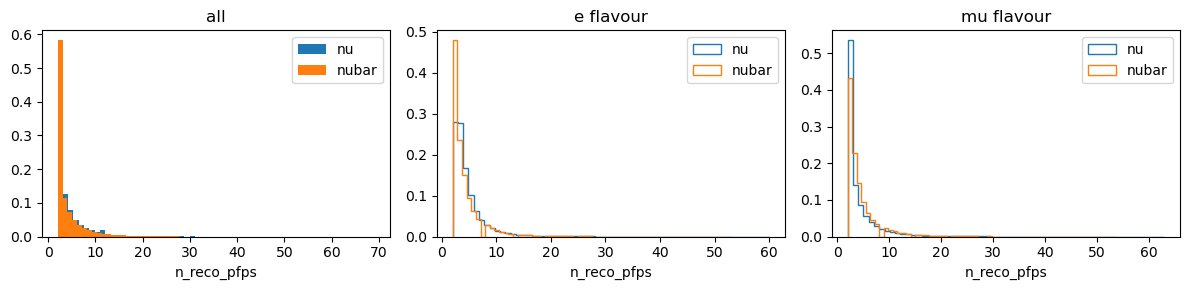

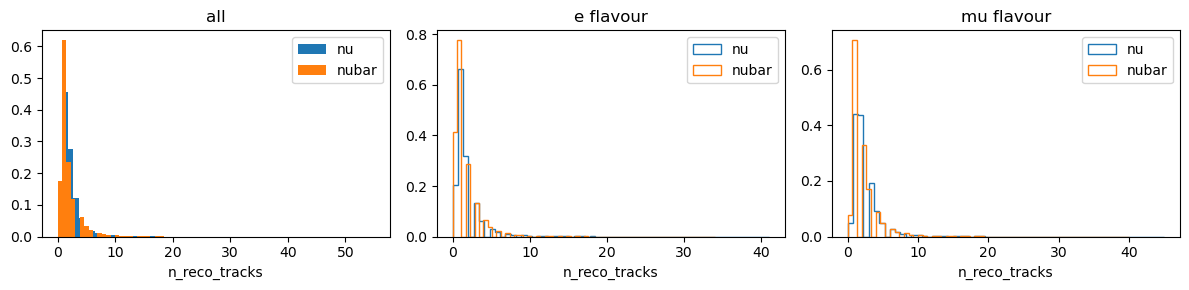

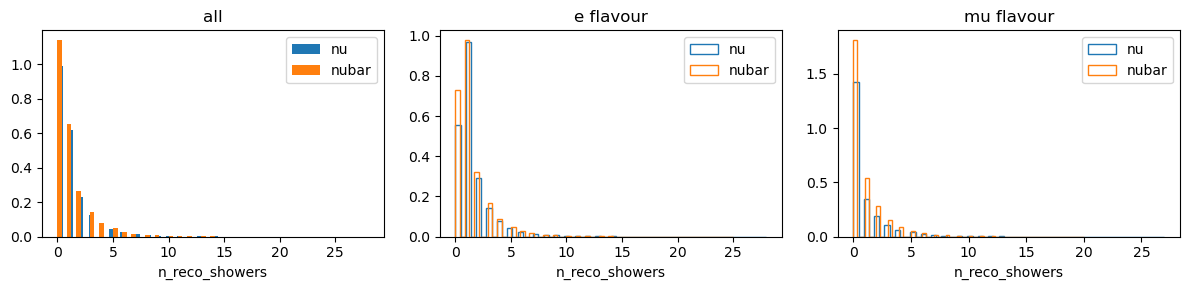

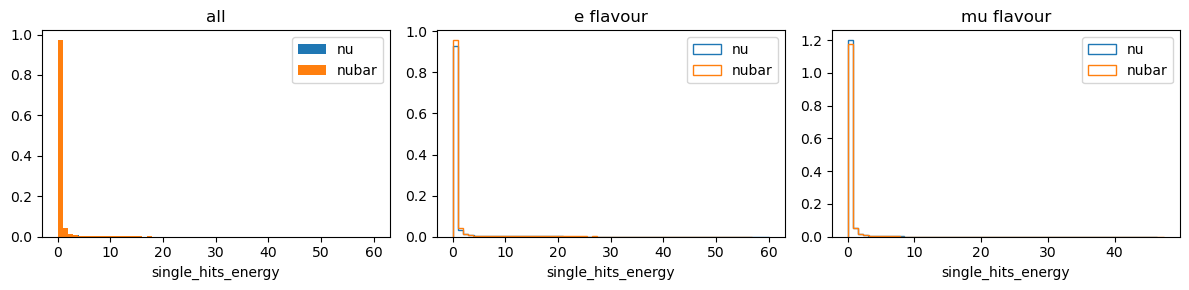

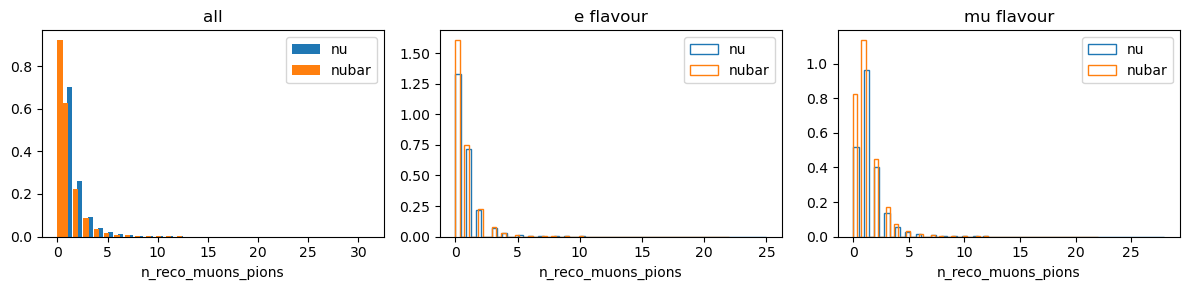

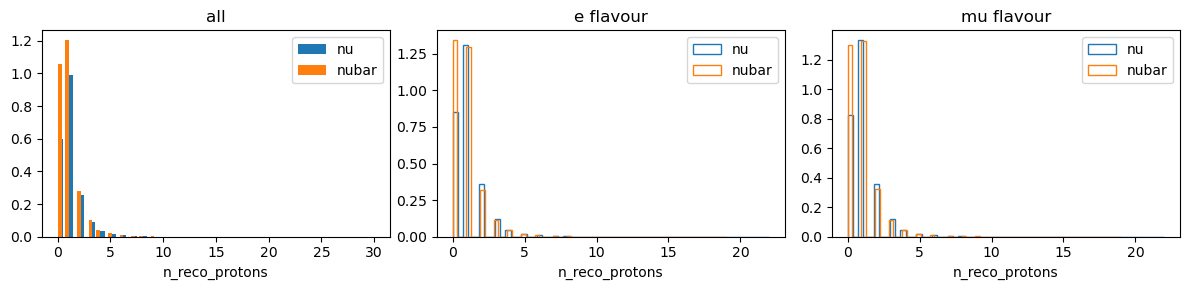

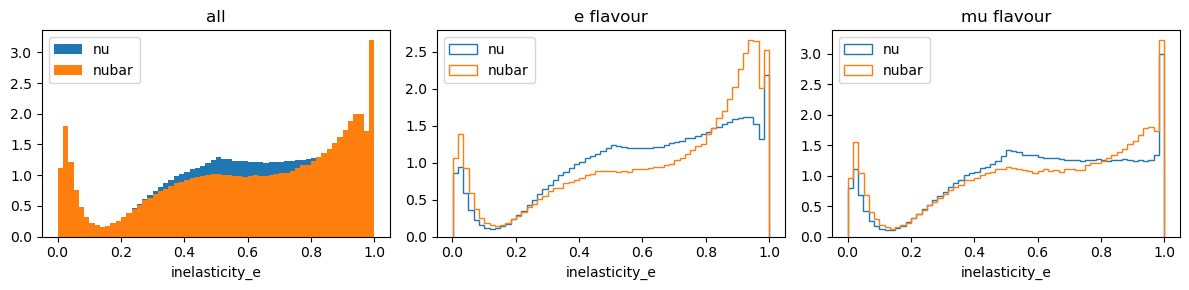

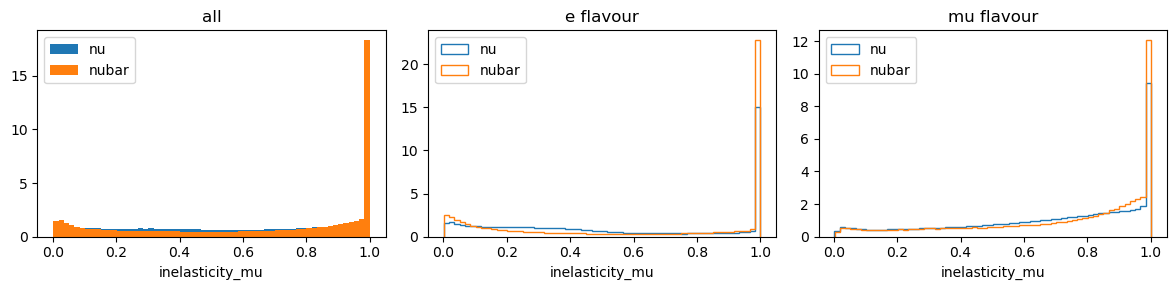

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

features = [
	"n_reco_pfps",
	"n_reco_tracks",
	"n_reco_showers",
	"single_hits_energy",
	"n_reco_muons_pions",
	"n_reco_protons",
	"inelasticity_e",
	"inelasticity_mu"
]

is_nu = plotting_data["label"] == 0
is_nubar = plotting_data["label"] == 1
is_e = np.abs(plotting_data["PDG"]) == 12
is_mu = np.abs(plotting_data["PDG"]) == 14

for feat in features:
	fig, axes = plt.subplots(1,3, figsize=(12,3))

	axes[0].hist(plotting_data[feat][is_nu], bins=60, density=True, histtype="step", label="nu")
	axes[0].hist(plotting_data[feat][is_nubar], bins=60, density=True, histtype="step", label="nubar")
	axes[0].set_title("all")

	axes[1].hist(plotting_data[feat][is_nu & is_e], bins=60, density=True, histtype="step", label="nu")
	axes[1].hist(plotting_data[feat][is_nubar & is_e], bins=60, density=True, histtype="step", label="nubar")
	axes[1].set_title("e flavour")

	axes[2].hist(plotting_data[feat][is_nu & is_mu], bins=60, density=True, histtype="step", label="nu")
	axes[2].hist(plotting_data[feat][is_nubar & is_mu], bins=60, density=True, histtype="step", label="nubar")
	axes[2].set_title("mu flavour")

	for ax in axes:
		ax.legend()
		ax.set_xlabel(feat)

	plt.tight_layout()
	plt.show()
